<a href="https://colab.research.google.com/github/RoshanMaharjan7/6S012-Artificial-Intelligence-and-Machine-Learning/blob/main/2408424_Roshan_Maharjan_Worksheet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [43]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Sem 6/AI/Week 5/FruitinAmazon.zip"
extract_path = "/content/fruits"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


Classes: ['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


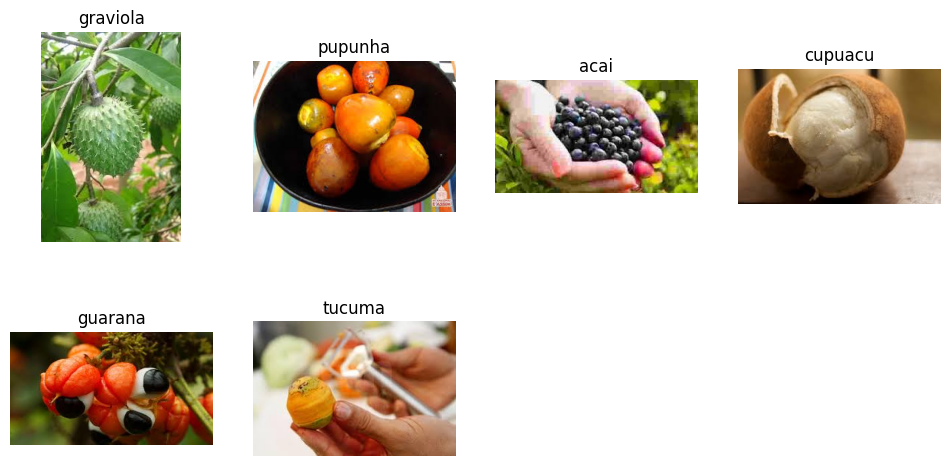

In [44]:
import matplotlib.pyplot as plt
import random
from PIL import Image

train_dir = os.path.join(extract_path, "FruitinAmazon/train")

classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image per class
images = []
labels = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Plot images
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.show()

In [45]:
corrupted = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [46]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [47]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(os.listdir(train_dir))

model = keras.Sequential([
    layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(num_classes, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
earlystop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,   # (you can set 250 as per sheet, but 50 is practical)
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.2060 - loss: 1.8962

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 660ms/step - accuracy: 0.1806 - loss: 1.9349 - val_accuracy: 0.1667 - val_loss: 1.9374
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.1285 - loss: 1.7995

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 575ms/step - accuracy: 0.1667 - loss: 1.7700 - val_accuracy: 0.1667 - val_loss: 1.8828
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.2234 - loss: 1.6871

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 577ms/step - accuracy: 0.2639 - loss: 1.6656 - val_accuracy: 0.1111 - val_loss: 1.8817
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 797ms/step - accuracy: 0.2639 - loss: 1.5073 - val_accuracy: 0.1111 - val_loss: 1.9155
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.3843 - loss: 1.3556

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 933ms/step - accuracy: 0.4028 - loss: 1.3540 - val_accuracy: 0.3333 - val_loss: 1.6162
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.6111 - loss: 1.1781 - val_accuracy: 0.3333 - val_loss: 1.7387
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 499ms/step - accuracy: 0.6111 - loss: 0.9430 - val_accuracy: 0.2778 - val_loss: 1.8605
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.7384 - loss: 0.7850

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 565ms/step - accuracy: 0.7778 - loss: 0.7383 - val_accuracy: 0.3889 - val_loss: 1.6023
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8657 - loss: 0.5390

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 552ms/step - accuracy: 0.8472 - loss: 0.5771 - val_accuracy: 0.6111 - val_loss: 1.5758
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 499ms/step - accuracy: 0.9722 - loss: 0.3292 - val_accuracy: 0.3889 - val_loss: 1.9152
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 488ms/step - accuracy: 0.8889 - loss: 0.2697 - val_accuracy: 0.4444 - val_loss: 2.9511
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 804ms/step - accuracy: 0.9583 - loss: 0.1860 - val_accuracy: 0.3889 - val_loss: 2.1684
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 485ms/step - accuracy: 0.9722 - loss: 0.1223 - val_accuracy: 0.3889 - val_loss: 2.3113
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 1.0000 - loss: 0.0458 - val_accuracy: 0.3333 - val_loss: 3.5150
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.9722 - loss: 0.1318 - val_accuracy: 0.5556 - val_loss: 2.0057
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 1.0000 - loss: 0.0767 - val_accuracy: 0.3333 - val_loss: 3.0

In [49]:
test_dir = os.path.join(extract_path, "FruitinAmazon/test")

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6333 - loss: 0.9085
Test Accuracy: 0.6333


In [50]:
# Save
model.save("fruit_model.h5")

# Load
loaded_model = keras.models.load_model("fruit_model.h5")

# Evaluate again
loss, acc = loaded_model.evaluate(test_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step - accuracy: 0.6333 - loss: 0.9085
Loaded Model Accuracy: 0.6333333253860474


In [51]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.50      0.40      0.44         5
           2       0.50      0.80      0.62         5
           3       0.83      1.00      0.91         5
           4       1.00      0.40      0.57         5
           5       0.50      0.40      0.44         5

    accuracy                           0.63        30
   macro avg       0.67      0.63      0.62        30
weighted avg       0.67      0.63      0.62        30



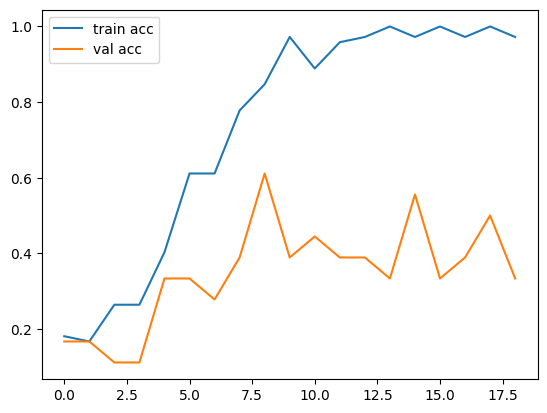

In [52]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()